In [29]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import math
from mosqlient.scoring import compute_wis

In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'../predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds = df_preds.loc[df_preds.adm_1 != 32]
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
def get_data(name = 'dengue_state'): 

    df = pd.read_csv(f'../data/{name}.csv.gz')

    return df

In [4]:
df_dengue_state = get_data('dengue_state')

df_dengue_state.date = pd.to_datetime(df_dengue_state.date)

df_dengue_state = df_dengue_state.loc[df_dengue_state.adm_1 != 32]


df_dengue_state.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Ranks: 

In [5]:
df_rk_1 = pd.read_csv('default_rk_1.csv.gz')
df_rk_2 = pd.read_csv('norm_rk_2.csv.gz')
df_rk_3 = pd.read_csv('diff_rk_3.csv.gz')
df_rk_4 = pd.read_csv('mean_rk_4.csv.gz')

In [6]:
def get_wis_model(df_preds, df_dengue_state, df_rk_1, label = 'rk_1', rank = 5):

    df_rk_1 = df_rk_1.loc[df_rk_1.adm_1 != 32] 

    list_dfs = [] 

    for adm in df_rk_1.adm_1.unique(): 


        models = df_rk_1.loc[(df_rk_1.adm_1 == adm) & (df_rk_1['rank'] <= rank)].model.unique()

        df_ = df_preds.loc[(df_preds.adm_1 == adm) & ( df_preds.model.isin(models))].groupby(['date', 'adm_1', 'validation'])[['lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                'upper_50', 'upper_80', 'upper_90', 'upper_95']].median().reset_index()

        df_m=df_.merge(df_dengue_state, on = ['date', 'adm_1']).sort_values(by = 'date')


        for val in [1,2,3,4]: 

                wis = np.mean(compute_wis(
                df = df_m.loc[df_m.validation == val][['date', 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                        'upper_50', 'upper_80', 'upper_90', 'upper_95']],
                observed_value=  df_m.loc[df_m.validation == val]['casos']))


                list_dfs.append(pd.DataFrame([[adm, val, wis]], columns = ['adm_1', 'validation', 'WIS' ]))



    df_wis_ = pd.concat(list_dfs, ignore_index=True)

    df_wis_['rank'] = label

    return df_wis_

    

In [7]:
df_wis_end = pd.DataFrame()

for df_rank, label in zip([df_rk_1, df_rk_2, df_rk_3, df_rk_4], ['rk_1', 'rk_2', 'rk_3', 'rk_4']): 
  
    df_wis = get_wis_model(df_preds, df_dengue_state, df_rank, label = label)

    df_wis_end = pd.concat([df_wis_end, df_wis], ignore_index = True)

df_wis_end.head()

,adm_1,validation,WIS,rank
0,14,1,2.337913,rk_1
1,14,2,3.219822,rk_1
2,14,3,2.537795,rk_1
3,14,4,4.032955,rk_1
4,28,1,13.017858,rk_1


In [8]:
df_wis_end['rank'].unique()

<ArrowStringArray>
['rk_1', 'rk_2', 'rk_3', 'rk_4']
Length: 4, dtype: str

In [9]:
df_wis_end['rank'].value_counts()

rank
rk_1    104
rk_2    104
rk_3    104
rk_4    104
Name: count, dtype: int64

In [10]:
df_wis_end.loc[(df_wis_end.adm_1 == 11) & (df_wis_end.validation == 1)]

,adm_1,validation,WIS,rank
80,11,1,67.590202,rk_1
104,11,1,74.755729,rk_2
208,11,1,73.191860,rk_3
312,11,1,73.148698,rk_4


In [11]:
best_rank = (
    df_wis_end.loc[df_wis_end.groupby(['adm_1', 'validation'])['WIS'].idxmin(),
           ['adm_1', 'validation', 'rank', 'WIS']]
    .reset_index(drop=True)
)

best_rank.head()

,adm_1,validation,rank,WIS
0,11,1,rk_1,67.590202
1,11,2,rk_4,30.317717
2,11,3,rk_3,13.028515
3,11,4,rk_2,15.419760
4,12,1,rk_3,20.907239


In [12]:
best_rank['rank'].value_counts()/best_rank.shape[0]

rank
rk_1    0.365385
rk_3    0.278846
rk_2    0.221154
rk_4    0.134615
Name: count, dtype: float64

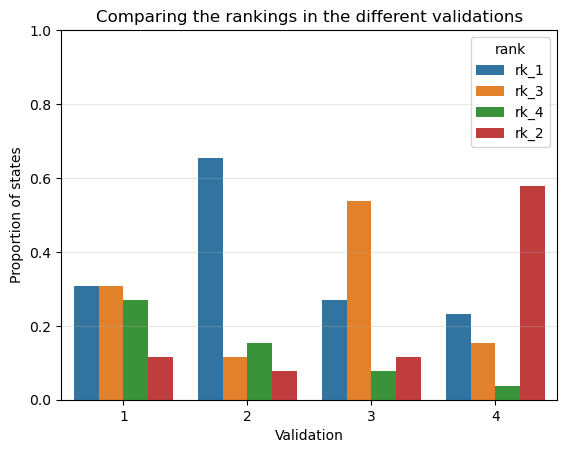

In [13]:
freq = (
    best_rank[['rank', 'validation']]
    .value_counts()
    .div(26)
    .rename('frequency')
    .reset_index()
)

sns.barplot(
    data=freq,
    x='validation',
    y='frequency',
    hue='rank'
)

plt.ylabel('Proportion of states')
plt.xlabel('Validation')
plt.ylim(0,1)
plt.grid(axis='y', alpha=.3)

plt.title('Comparing the rankings in the different validations')

plt.savefig('comp_rank_prop.png', dpi=300, bbox_inches = 'tight')


In [22]:
df_wis_end.loc[df_wis_end.adm_1 == 11].head()

,adm_1,validation,WIS,rank
80,11,1,67.590202,rk_1
81,11,2,30.445385,rk_1
82,11,3,17.374231,rk_1
83,11,4,21.774797,rk_1
104,11,1,74.755729,rk_2


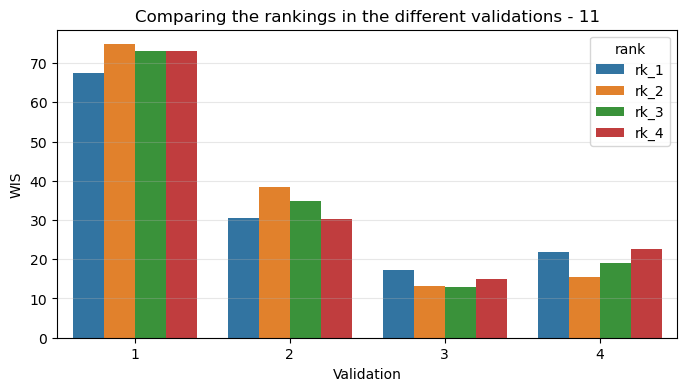

In [28]:
_,ax = plt.subplots(figsize = (8, 4))

state = 11 
absolute_wis = df_wis_end.loc[df_wis_end.adm_1 == state]

sns.barplot(
    data=absolute_wis,
    x='validation',
    y='WIS',
    hue='rank'
)

plt.ylabel('WIS')
plt.xlabel('Validation')
#plt.ylim(0,1)
plt.grid(axis='y', alpha=.3)

plt.title(f'Comparing the rankings in the different validations - {state}')

#plt.savefig('comp_rank_prop.png', dpi=300, bbox_inches = 'tight')

plt.show()

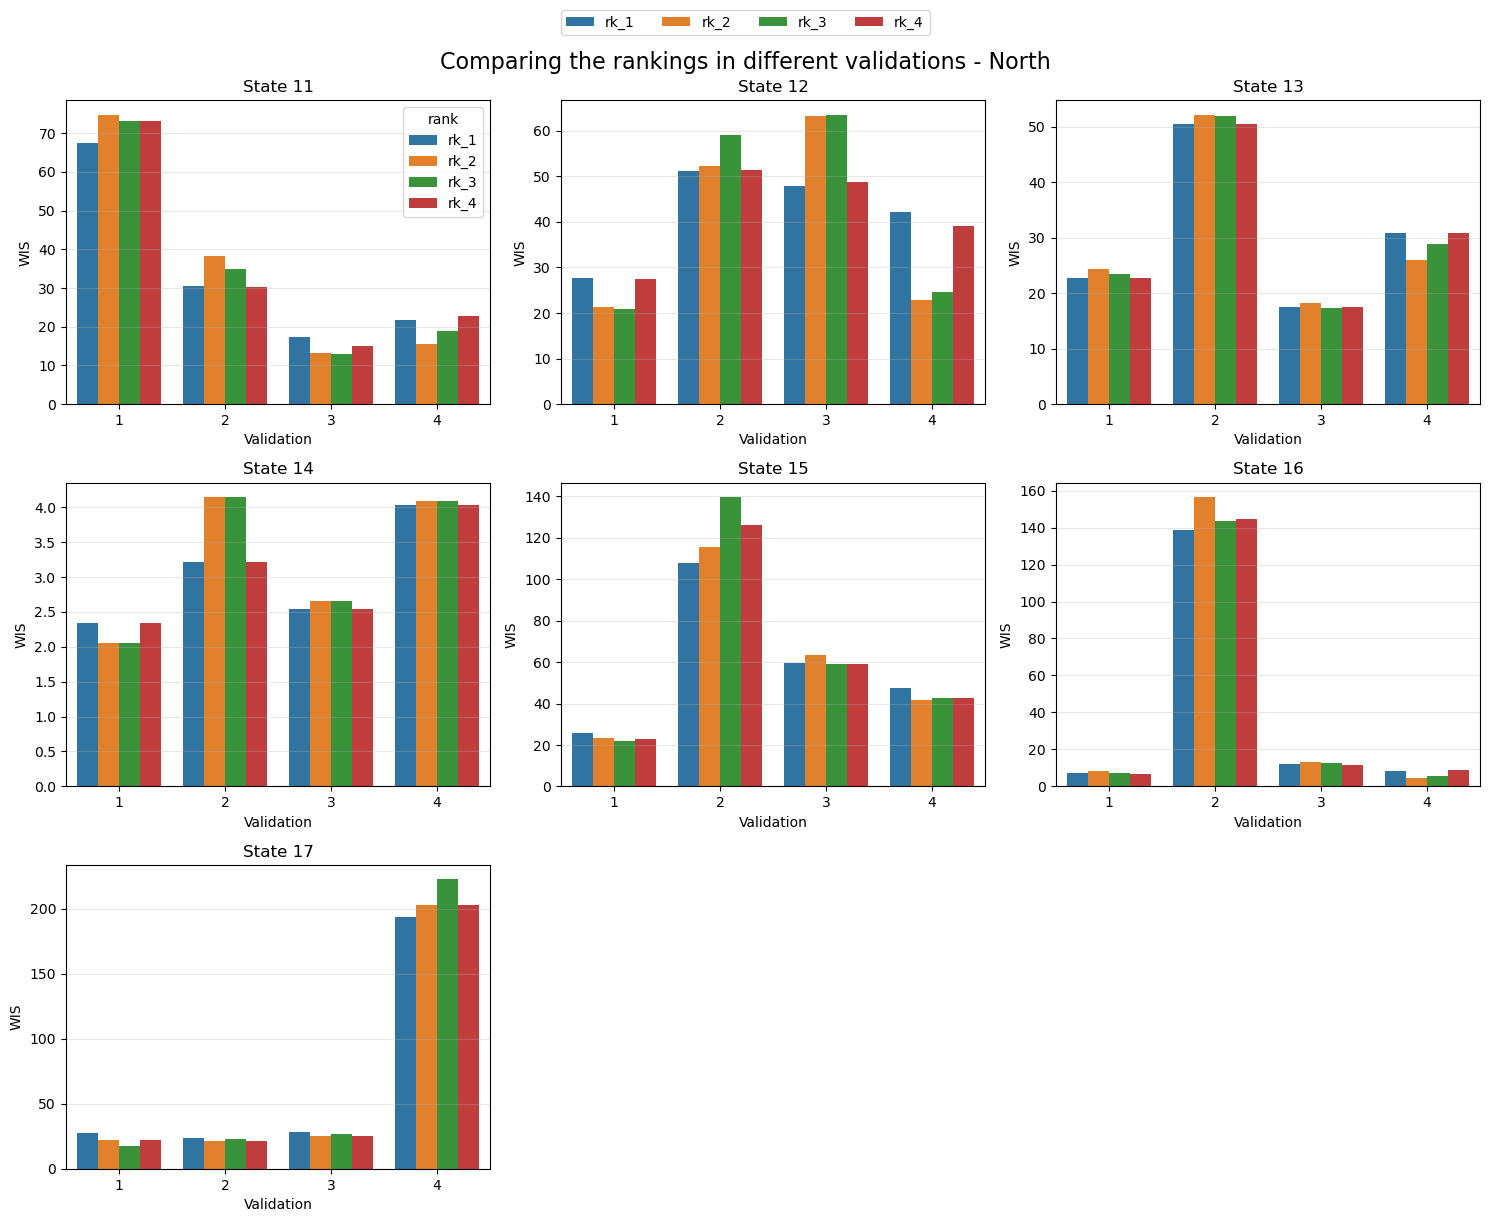

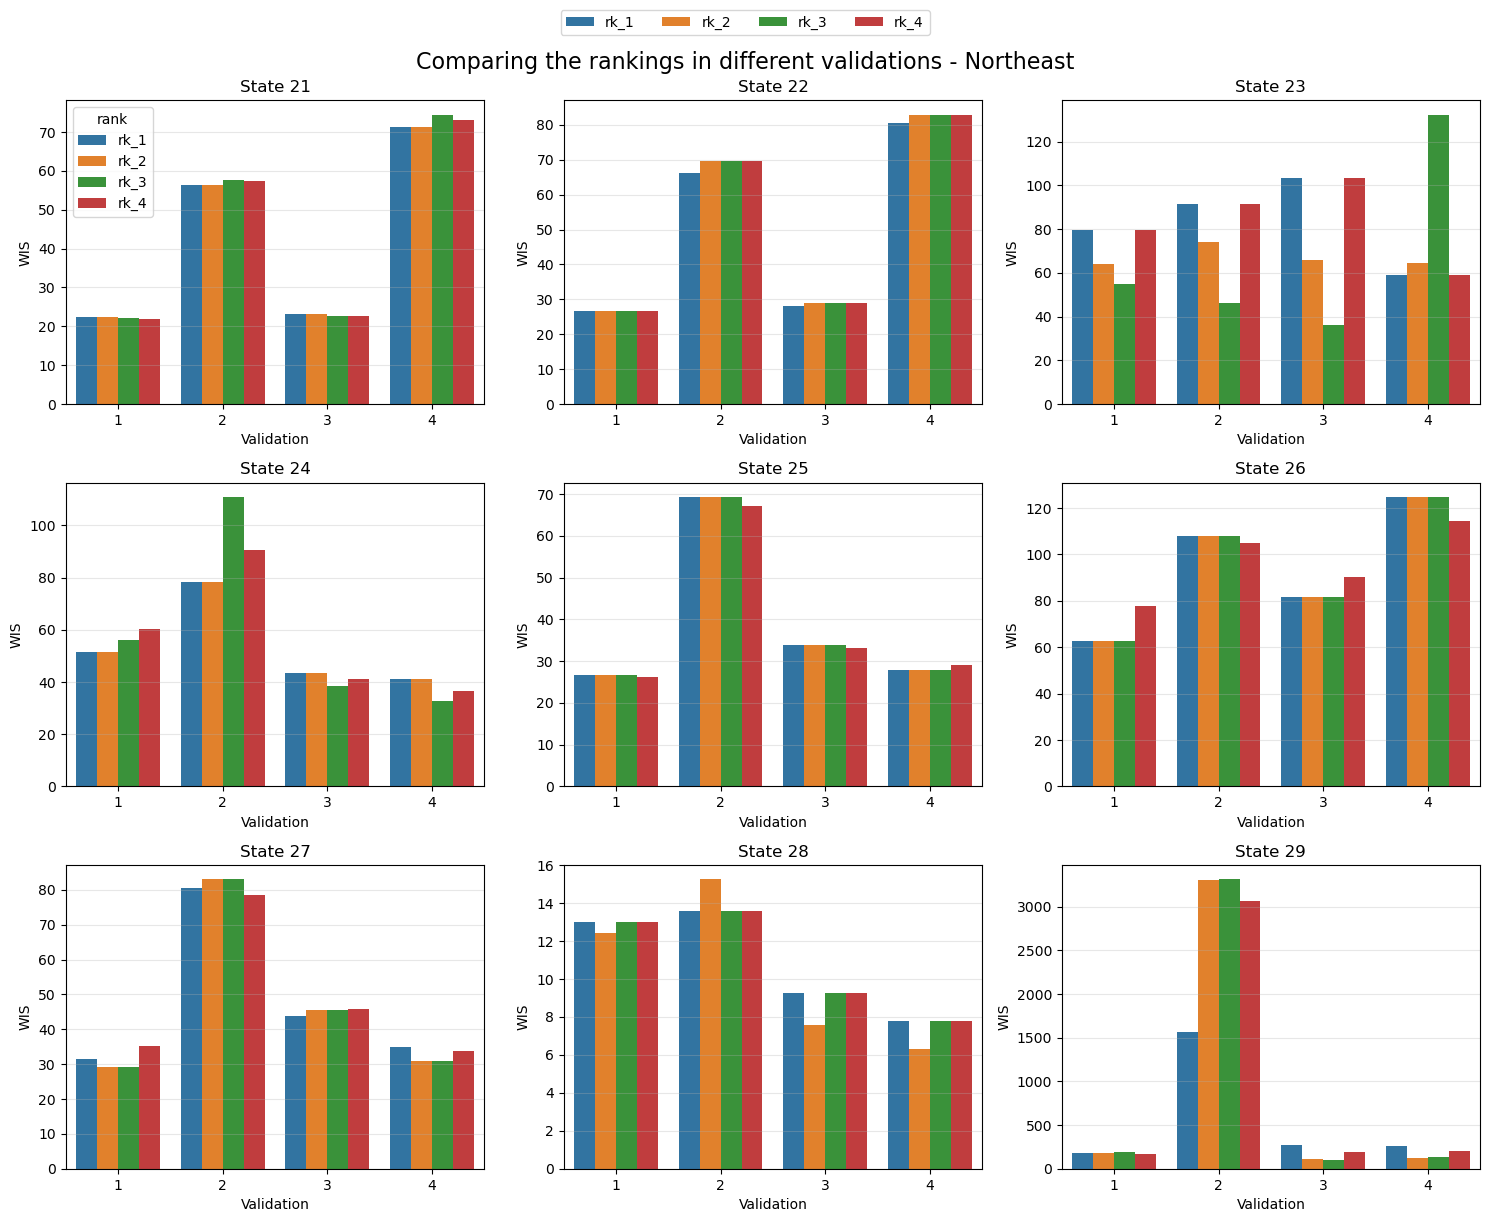

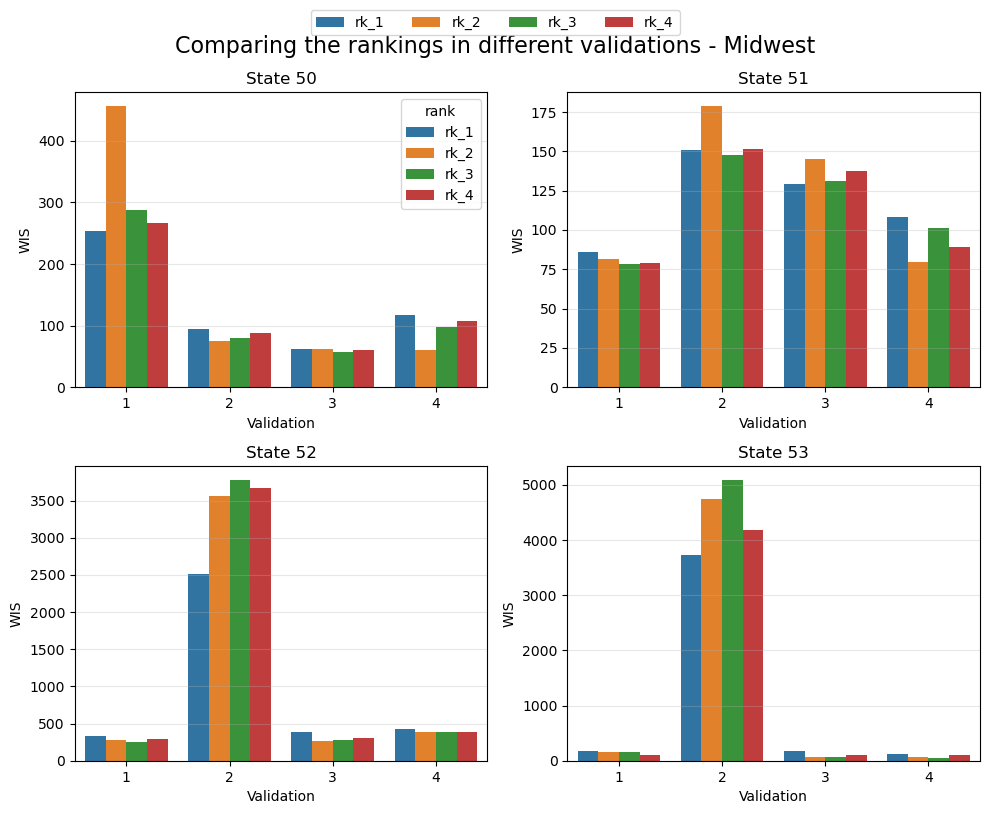

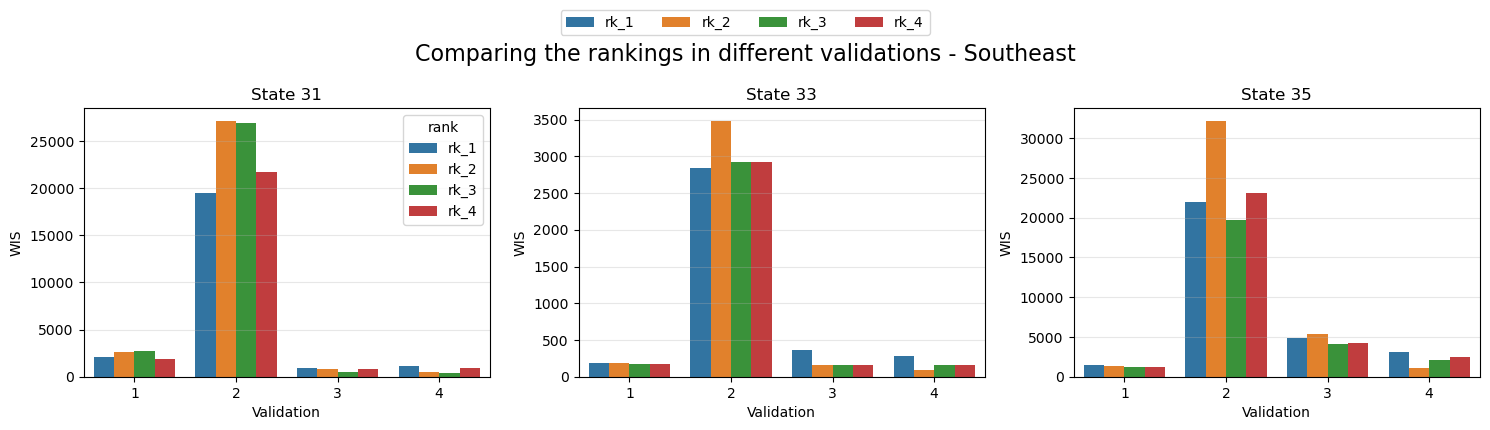

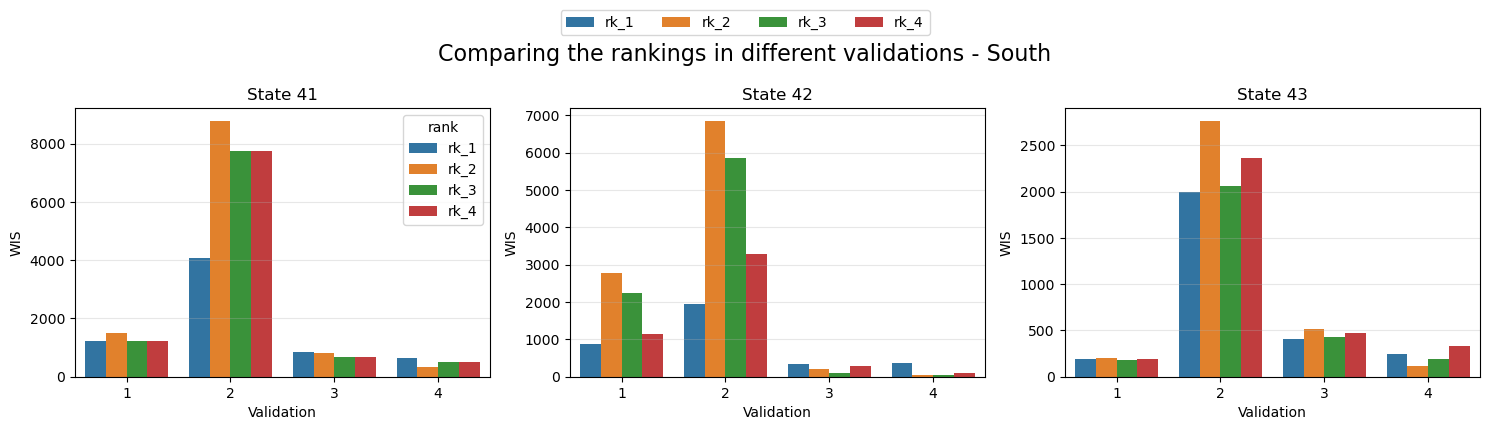

In [37]:
# Regiões do Brasil (código IBGE -> nome)
regions = {
    "North":      [11, 12, 13, 14, 15, 16, 17],
    "Northeast":  [21, 22, 23, 24, 25, 26, 27, 28, 29],
    "Midwest":    [50, 51, 52, 53],
    "Southeast":  [31, 33, 35],
    "South":      [41, 42, 43],
}

state_names = {
    11:"RO", 12:"AC", 13:"AM", 14:"RR", 15:"PA", 16:"AP", 17:"TO",
    21:"MA", 22:"PI", 23:"CE", 24:"RN", 25:"PB", 26:"PE", 27:"AL", 28:"SE", 29:"BA",
    31:"MG", 32:"ES", 33:"RJ", 35:"SP",
    41:"PR", 42:"SC", 43:"RS",
    50:"MS", 51:"MT", 52:"GO", 53:"DF"
}

# Número de colunas em cada figura

for region, states in regions.items():

    if region == 'Midwest': 
        ncols = 2
    else: 
        ncols = 3


    n_states = len(states)
    nrows = math.ceil(n_states / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5*ncols, 4*nrows),
        sharey=False
    )

    axes = axes.flatten()

    for ax, state in zip(axes, states):

        absolute_wis = df_wis_end.loc[df_wis_end.adm_1 == state]

        sns.barplot(
            data=absolute_wis,
            x="validation",
            y="WIS",
            hue="rank",
            ax=ax
        )

        ax.set_title(f"State {state}")
        ax.set_xlabel("Validation")
        ax.set_ylabel("WIS")
        ax.grid(axis="y", alpha=0.3)

        # Manter legenda apenas no primeiro subplot
        if ax != axes[0]:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    # Remove eixos vazios
    for ax in axes[n_states:]:
        fig.delaxes(ax)

    # Legenda única

    if region in ['South', 'Southeast']:
        height_y = 1.08 
    else: 
        height_y = 1.02

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, height_y )
    )

    fig.suptitle(
        f"Comparing the rankings in different validations - {region}",
        fontsize=16
    )

    plt.tight_layout()

    plt.savefig(
        f"figures/ranking_comparison_{region.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [14]:
best_rank

,adm_1,validation,rank,WIS
0,11,1,rk_1,67.590202
1,11,2,rk_4,30.317717
2,11,3,rk_3,13.028515
3,11,4,rk_2,15.419760
4,12,1,rk_3,20.907239
...,...,...,...,...
99,52,4,rk_3,380.092801
100,53,1,rk_4,110.923711
101,53,2,rk_1,3729.816688
102,53,3,rk_3,67.961888


In [23]:
best_rank[['rank', 'validation']].value_counts()/26

rank  validation
rk_1  2             0.653846
rk_2  4             0.576923
rk_3  3             0.538462
rk_1  1             0.307692
rk_3  1             0.307692
rk_1  3             0.269231
rk_4  1             0.269231
rk_1  4             0.230769
rk_4  2             0.153846
rk_3  4             0.153846
rk_2  1             0.115385
      3             0.115385
rk_3  2             0.115385
rk_4  3             0.076923
rk_2  2             0.076923
rk_4  4             0.038462
Name: count, dtype: float64

In [13]:
best_rank.loc[best_rank['rank'] == 'rk_1']['validation'].value_counts()

validation
2    17
1     8
3     7
4     6
Name: count, dtype: int64

In [14]:
best_rank.loc[best_rank['rank'] == 'rk_3']['validation'].value_counts()

validation
3    14
1     8
4     4
2     3
Name: count, dtype: int64

In [15]:
best_rank.loc[best_rank['rank'] == 'rk_3']['adm_1'].value_counts()

adm_1
23    3
15    2
24    2
31    2
33    2
35    2
51    2
52    2
53    2
11    1
12    1
13    1
17    1
21    1
29    1
41    1
42    1
43    1
50    1
Name: count, dtype: int64

In [28]:
df_rk_1 = df_wis_end.loc[df_wis_end['rank'] == 'rk_1'].rename(columns = {'WIS': "WIS_rk1"})
df_rk_3 = df_wis_end.loc[df_wis_end['rank'] == 'rk_3'].rename(columns = {'WIS': "WIS_rk3"})

df_m = df_rk_1.merge(df_rk_3, on = ['adm_1', 'validation'])

df_m['diff_WIS'] = df_m['WIS_rk3'] - df_m['WIS_rk1']

df_m['ratio_WIS'] = df_m['WIS_rk3']/df_m['WIS_rk1']

df_m.head()

,adm_1,validation,WIS_rk1,rank_x,WIS_rk3,rank_y,diff_WIS,ratio_WIS
0,14,1,2.337913,rk_1,2.051020,rk_3,-0.286893,0.877287
1,14,2,3.219822,rk_1,4.143874,rk_3,0.924052,1.286989
2,14,3,2.537795,rk_1,2.662100,rk_3,0.124305,1.048981
3,14,4,4.032955,rk_1,4.082890,rk_3,0.049935,1.012382
4,28,1,13.017858,rk_1,13.017858,rk_3,0.000000,1.000000


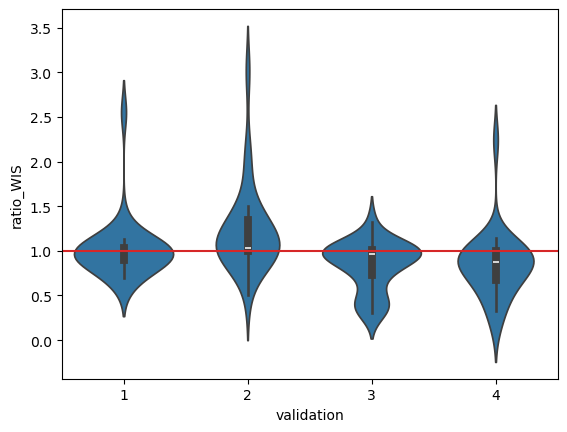

In [32]:
_, ax= plt.subplots()
sns.violinplot(
    data=df_m,
    x="validation",
    y="ratio_WIS", 
    ax=ax
)

ax.axhline(1, color = 'tab:red')


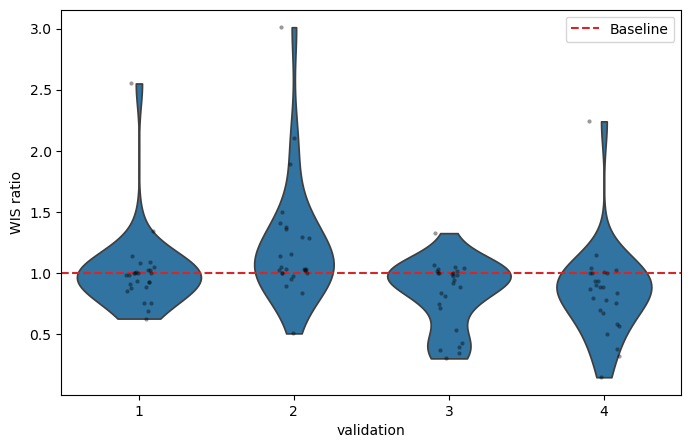

In [33]:

fig, ax = plt.subplots(figsize=(8,5))

sns.violinplot(
    data=df_m,
    x="validation",
    y="ratio_WIS",
    inner=None,
    cut=0,
    ax=ax
)

sns.stripplot(
    data=df_m,
    x="validation",
    y="ratio_WIS",
    color="black",
    alpha=0.4,
    size=3,
    jitter=True,
    ax=ax
)

ax.axhline(1, color="tab:red", linestyle="--", label="Baseline")

ax.set_ylabel("WIS ratio")
ax.legend()

plt.show()

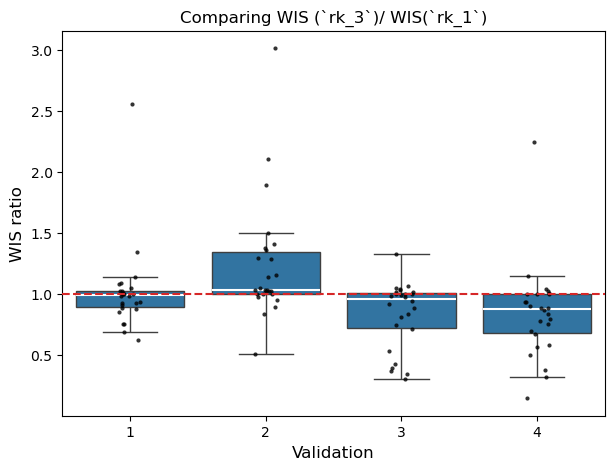

In [44]:
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    data=df_m,
    x="validation",
    y="ratio_WIS",
    showfliers=False,
    color = 'tab:blue',
    ax=ax,
        medianprops={
        "color": "white",
        "linewidth": 1.5
    },

)

sns.stripplot(
    data=df_m,
    x="validation",
    y="ratio_WIS",
    color="black",
    alpha=0.8,
    size=3,
    jitter=True,
    ax=ax
)

ax.axhline(1, color="tab:red", linestyle="--", zorder = 5)

ax.set_ylabel("WIS ratio", fontsize = 12)

ax.set_xlabel("Validation", fontsize = 12)

ax.set_title('Comparing WIS (`rk_3`)/ WIS(`rk_1`)')

plt.show()

In [56]:
df_m.loc[df_m.ratio_WIS < 1][['validation']].value_counts()/26

validation
4             0.692308
3             0.615385
1             0.500000
2             0.192308
Name: count, dtype: float64

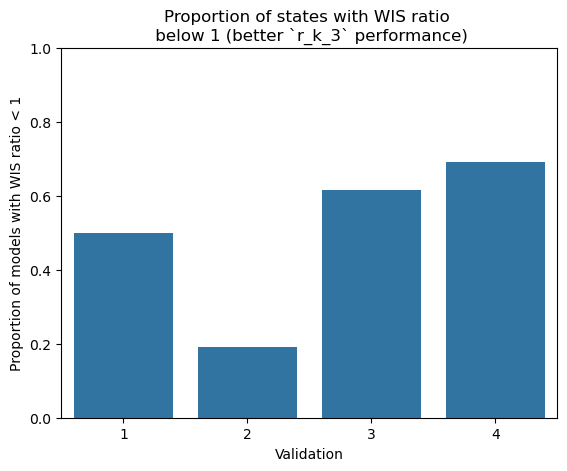

In [65]:
df_prop = (
    df_m.loc[df_m.ratio_WIS < 1, ['validation']]
    .value_counts()
    .div(26)
    .reset_index(name="proportion")
)

_,ax = plt.subplots()

sns.barplot(
    data=df_prop,
    x="validation",
    y="proportion",
    color="tab:blue",
    ax=ax
)

ax.set_ylabel("Proportion of models with WIS ratio < 1")
ax.set_xlabel("Validation")
ax.set_ylim(0, 1)

ax.set_title('Proportion of states with WIS ratio \n below 1 (better `r_k_3` performance)')

plt.savefig('prop_below_one.png', dpi = 300, bbox_inches = 'tight')
plt.show()